In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import gcamp_peak_utils as gp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

In [2]:
def avg_rate_by_spatial_bins(df, n_bins=32, x_col="X_coor", cell_prefix="cell_"):
    # cell columns = everything that starts with "cell_"
    cell_cols = [c for c in df.columns if c.startswith(cell_prefix)]

    # equal-width bins across observed X range
    edges = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)
    xbin = pd.cut(df[x_col], bins=edges, include_lowest=True, labels=False)

    # mean rate per bin per cell + occupancy
    out = df[cell_cols].groupby(xbin).mean()
    out.index.name = "x_bin"
    out["n_samples"] = xbin.value_counts().sort_index().to_numpy()
    out["x_left"] = edges[:-1]
    out["x_right"] = edges[1:]
    out["x_center"] = (edges[:-1] + edges[1:]) / 2
    return out

def normalize_peak_to_one(df, cell_prefix="cell_"):
    out = df.copy()
    cell_cols = [c for c in out.columns if c.startswith(cell_prefix)]
    peak = out[cell_cols].max(axis=0)                 # max per cell across bins
    peak = peak.replace(0, np.nan)                    # avoid divide-by-zero
    out[cell_cols] = out[cell_cols].div(peak, axis=1) # each cell scaled so max==1
    return out

def plot_spatial_rate_heatmap(
    df,
    cells=None,
    cell_prefix="cell_",
    sort_by_peak_bin=False,
    use_x_centers=True,
    title="Spatial firing rate heatmap",
    figsize=(10, 8),
    aspect="auto",
    label_all_cells=True,
    alternate_sides=True,
    label_fontsize=7,
    label_pad=0.6,
    save_path=None,
    show=True,
    return_fig=False,
):
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path

    all_cell_cols = [c for c in df.columns if c.startswith(cell_prefix)]
    if cells is None:
        cell_cols = all_cell_cols
    else:
        cell_cols = [c for c in cells if c in df.columns]
        if len(cell_cols) == 0:
            raise ValueError("None of the requested cells were found in df columns.")

    mat = df[cell_cols].to_numpy().T

    if sort_by_peak_bin and mat.shape[0] > 0:
        peak_bins = np.nanargmax(np.nan_to_num(mat, nan=-np.inf), axis=1)
        order = np.argsort(peak_bins)
        mat = mat[order, :]
        cell_cols = [cell_cols[i] for i in order]

    if use_x_centers and ("x_center" in df.columns):
        x = df["x_center"].to_numpy()
        x_label = "X position (bin center)"
    else:
        x = np.arange(mat.shape[1])
        x_label = "Spatial bin"

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mat, interpolation="nearest", aspect=aspect)
    fig.colorbar(im, ax=ax, label="Firing rate (raw or normalized)")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Cell")
    ax.set_title(title)

    n_bins = mat.shape[1]
    if n_bins > 1:
        xt = np.linspace(0, n_bins - 1, min(10, n_bins)).astype(int)
        ax.set_xticks(xt)
        ax.set_xticklabels(
            [f"{x[i]:.1f}" if use_x_centers and ("x_center" in df.columns) else str(i) for i in xt],
            rotation=45, ha="right"
        )

    n_cells = mat.shape[0]

    if label_all_cells:
        ax.set_yticks([])
        left_x = -0.5 - label_pad
        right_x = (n_bins - 1) + 0.5 + label_pad
        ax.set_xlim(left_x, right_x)

        for r, name in enumerate(cell_cols):
            if alternate_sides:
                if (r % 2) == 0:
                    ax.text(-0.5 - label_pad, r, name, va="center", ha="right", fontsize=label_fontsize)
                else:
                    ax.text((n_bins - 1) + 0.5 + label_pad, r, name, va="center", ha="left", fontsize=label_fontsize)
            else:
                ax.text(-0.5 - label_pad, r, name, va="center", ha="right", fontsize=label_fontsize)
    else:
        ax.set_yticks(np.arange(n_cells))
        ax.set_yticklabels(cell_cols)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, format=save_path.suffix.lstrip(".") or "pdf", bbox_inches="tight")
        print(save_path)

    if show:
        plt.show()

    if return_fig:
        return fig, ax


def get_session_subset(gcamp_df, onsets_df, session_src):
    mask = gcamp_df["ezTrackOutput"].astype(str) == str(session_src)

    session_gcamp = gcamp_df.loc[mask].reset_index(drop=True)
    session_onsets = onsets_df.loc[mask].reset_index(drop=True)

    session_onsets = session_onsets.copy()
    session_onsets["X_coor"] = session_gcamp["X_coor"].to_numpy()
    session_onsets["Y_coor"] = session_gcamp["Y_coor"].to_numpy()
    session_onsets["closestBehavCamFrameIdx"] = session_gcamp["closestBehavCamFrameIdx"].to_numpy()

    return session_gcamp, session_onsets

def get_peak_sorted_cell_order(spatial_rates_df, cell_prefix="cell_"):
    cell_cols = [c for c in spatial_rates_df.columns if c.startswith(cell_prefix)]

    if len(cell_cols) == 0:
        return []

    mat = spatial_rates_df[cell_cols].to_numpy().T
    peak_bins = np.nanargmax(np.nan_to_num(mat, nan=-np.inf), axis=1)
    order = np.argsort(peak_bins)

    return [cell_cols[i] for i in order]



In [3]:
base_dir = Path("/scratch/jma819/CaliAli_linearTrackData")
analysis_dirs = sorted(base_dir.glob("m*_analysis"))
summary_rows = []
for analysis_dir in analysis_dirs:
    gcamp_path = analysis_dir / "GCAMP_with_velocity.csv"
    out_path = analysis_dir / "all_peak_stats.csv"
    if not gcamp_path.exists():
        print(f"Skipping {analysis_dir.name}: no GCAMP_with_velocity.csv")
        continue

    print(f"Processing {analysis_dir.name}")

    gcamp_df = gp.load_aligned_gcamp_df(gcamp_path)
    cell_cols = [c for c in gcamp_df.columns if c.startswith("cell_")]

    if not cell_cols:
        print(f"  No cell columns found in {gcamp_path.name}")
        continue

    aligned_GCAMP = gcamp_df[cell_cols]

    signalPeaks = gp.detect_peaks_df(
        aligned_GCAMP,
        threshold=2.5,
        smooth_window_samples=3,
        min_peak_prominence=1.5,
        min_peak_distance_samples=20,
        min_peak_width_samples=2,
        return_to_baseline_tol=0.4,
        return_to_baseline_window_samples=5,
    )

    all_stats_df = gp.compute_peak_stats_for_all_cells_from_gcamp_df(
        gcamp_df,
        signalPeaks,
        tol=0.25,
        window_len_onset=3,
        window_len_offset=3,
        plt_region=10,
        behavior_columns=["X_coor", "Y_coor", "Velocity_spatial_filtered"],
        output_csv_path=out_path,
    )

    summary_rows.append({
        "analysis_dir": analysis_dir.name,
        "gcamp_file": str(gcamp_path),
        "output_csv": str(out_path),
        "n_cells": len(cell_cols),
        "n_events": len(all_stats_df),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

Processing m311_analysis


KeyboardInterrupt: 

In [4]:
base_dir = Path("/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackDataAlignedAcrossDays")
analysis_dirs = sorted(base_dir.glob("m*_analysis"))

velocity_bins = [(0, 0.5), (0.5, 2), (2, 5), (5, 10), (10, np.inf)]

summary_rows = []
mismatch_rows = []

for analysis_dir in analysis_dirs:
    gcamp_path = analysis_dir / "GCAMP_with_velocity.csv"
    rate_path = analysis_dir / "instantaneousEventRate.csv"
    rate_onsets_path = analysis_dir / "instantaneousEventRateOnsets.csv"
    avg_out_path = analysis_dir / "avg_event_rate_by_speed_bins.csv"
    avg_onsets_out_path = analysis_dir / "avg_event_rate_onsets_by_speed_bins.csv"

    if not (gcamp_path.exists() and rate_path.exists() and rate_onsets_path.exists()):
        summary_rows.append({
            "analysis_dir": analysis_dir.name,
            "status": "missing_input_csv"
        })
        continue

    try:
        print(f"Processing {analysis_dir.name}")

        GCAMP_with_velocity = pd.read_csv(gcamp_path, index_col=0).reset_index(drop=True)
        instantaneousEventRate = pd.read_csv(rate_path, index_col=0).reset_index(drop=True)
        instantaneousEventRateOnsets = pd.read_csv(rate_onsets_path, index_col=0).reset_index(drop=True)

        len_gcamp = len(GCAMP_with_velocity)
        len_rate = len(instantaneousEventRate)
        len_onsets = len(instantaneousEventRateOnsets)

        if len_rate != len_gcamp or len_onsets != len_gcamp:
            mismatch_rows.append({
                "analysis_dir": analysis_dir.name,
                "len_gcamp": len_gcamp,
                "len_rate": len_rate,
                "len_onsets": len_onsets,
            })

        velocity = GCAMP_with_velocity["Velocity_spatial_filtered"]

        instantaneousEventRate["Velocity_spatial_filtered"] = velocity.iloc[:len_rate].reset_index(drop=True)
        instantaneousEventRateOnsets["Velocity_spatial_filtered"] = velocity.iloc[:len_onsets].reset_index(drop=True)

        velocity_bin_ilocs_rate = {
            (lo, hi): np.flatnonzero(
                (
                    (instantaneousEventRate["Velocity_spatial_filtered"] >= lo) &
                    ((instantaneousEventRate["Velocity_spatial_filtered"] < hi) if np.isfinite(hi) else True)
                ).to_numpy()
            ).tolist()
            for lo, hi in velocity_bins
        }

        velocity_bin_ilocs_onsets = {
            (lo, hi): np.flatnonzero(
                (
                    (instantaneousEventRateOnsets["Velocity_spatial_filtered"] >= lo) &
                    ((instantaneousEventRateOnsets["Velocity_spatial_filtered"] < hi) if np.isfinite(hi) else True)
                ).to_numpy()
            ).tolist()
            for lo, hi in velocity_bins
        }

        avg_rates = avg_event_rate_by_speed_bins(
            instantaneousEventRate,
            velocity_bin_ilocs_rate,
            speed_col="Velocity_spatial_filtered"
        )

        avg_rates_onsets = avg_event_rate_by_speed_bins(
            instantaneousEventRateOnsets,
            velocity_bin_ilocs_onsets,
            speed_col="Velocity_spatial_filtered"
        )

        avg_rates.to_csv(avg_out_path)
        avg_rates_onsets.to_csv(avg_onsets_out_path)

        summary_rows.append({
            "analysis_dir": analysis_dir.name,
            "status": "ok",
            "len_gcamp": len_gcamp,
            "len_rate": len_rate,
            "len_onsets": len_onsets,
            "avg_rates_csv": str(avg_out_path),
            "avg_rates_onsets_csv": str(avg_onsets_out_path),
        })

    except Exception as e:
        summary_rows.append({
            "analysis_dir": analysis_dir.name,
            "status": "error",
            "error": str(e),
        })
        continue

summary_df = pd.DataFrame(summary_rows)
mismatch_df = pd.DataFrame(mismatch_rows)

summary_df



Processing m311_analysis
Processing m326_analysis
Processing m328_analysis
Processing m388_analysis
Processing m752_analysis
Processing m757_analysis
Processing m989_analysis
Processing m992_analysis
Processing m994_analysis


,analysis_dir,status,len_gcamp,len_rate,len_onsets,avg_rates_csv,avg_rates_onsets_csv
0,m311_analysis,ok,271420,271420,271420,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...
1,m326_analysis,ok,236925,236925,236925,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...
2,m328_analysis,ok,236913,236913,236913,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...
3,m388_analysis,ok,236928,236928,236928,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...
4,m752_analysis,ok,211378,211378,211378,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...
5,m757_analysis,ok,100855,100855,100855,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...
6,m989_analysis,ok,226208,226208,226208,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...
7,m992_analysis,ok,291847,291847,291847,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...
8,m994_analysis,ok,243048,243048,129340,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...,/Volumes/fsmresfiles/Basic_Sciences/Phys/Contr...


In [3]:
summary_df

NameError: name 'summary_df' is not defined

In [ ]:
## mice are 
# WT: [992, 994, 989, 757, 326, 311]
# KO: [752, 328, 388]

In [4]:
base_dir = Path("/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackDataAlignedAcrossDays")
analysis_dirs = sorted(base_dir.glob("m*_analysis"))

all_rates = []
all_onsets = []
missing = []

for analysis_dir in analysis_dirs:
    rates_path = analysis_dir / "avg_event_rate_by_speed_bins.csv"
    onsets_path = analysis_dir / "avg_event_rate_onsets_by_speed_bins.csv"

    if not rates_path.exists() or not onsets_path.exists():
        missing.append(analysis_dir.name)
        continue

    mouse_name = analysis_dir.name.replace("_analysis", "")

    # read multiindex rows: low, high
    rates_df = pd.read_csv(rates_path, index_col=[0, 1])
    onsets_df = pd.read_csv(onsets_path, index_col=[0, 1])

    # long format
    rates_long = (
        rates_df
        .reset_index()
        .rename(columns={"low": "speed_bin_low", "high": "speed_bin_high"})
        .melt(
            id_vars=["speed_bin_low", "speed_bin_high"],
            var_name="cell",
            value_name="avg_rate"
        )
    )
    rates_long["mouse"] = mouse_name

    onsets_long = (
        onsets_df
        .reset_index()
        .rename(columns={"low": "speed_bin_low", "high": "speed_bin_high"})
        .melt(
            id_vars=["speed_bin_low", "speed_bin_high"],
            var_name="cell",
            value_name="avg_rate_onsets"
        )
    )
    onsets_long["mouse"] = mouse_name

    all_rates.append(rates_long)
    all_onsets.append(onsets_long)

all_rates_df = pd.concat(all_rates, ignore_index=True) if all_rates else pd.DataFrame()
all_onsets_df = pd.concat(all_onsets, ignore_index=True) if all_onsets else pd.DataFrame()

missing


[]

In [22]:
# reprocess velocity


In [ ]:
## mice are 
# WT: [992, 994, 989, 757, 326, 311]
# KO: [752, 328, 388]

In [5]:
##WT mice: [992, 994, 989, 757, 326, 311]  
m992_onsets_avg_across_cells = (
    all_onsets_df.loc[all_onsets_df["mouse"] == "m992"]
    .groupby(["speed_bin_low", "speed_bin_high"], dropna=False)["avg_rate_onsets"]
    .mean()
    .reset_index(name="mean_avg_rate_onsets_across_cells")
)

m992_onsets_avg_across_cells

,speed_bin_low,speed_bin_high,mean_avg_rate_onsets_across_cells
0,0.0,0.5,0.163350
1,0.5,2.0,0.180244
2,2.0,5.0,0.195819
3,5.0,10.0,0.206452
4,10.0,inf,0.224650


In [6]:
m994_onsets_avg_across_cells = (
    all_onsets_df.loc[all_onsets_df["mouse"] == "m994"]
    .groupby(["speed_bin_low", "speed_bin_high"], dropna=False)["avg_rate_onsets"]
    .mean()
    .reset_index(name="mean_avg_rate_onsets_across_cells")
)

m994_onsets_avg_across_cells

,speed_bin_low,speed_bin_high,mean_avg_rate_onsets_across_cells
0,0.0,0.5,0.122460
1,0.5,2.0,0.128296
2,2.0,5.0,0.127721
3,5.0,10.0,0.129082
4,10.0,inf,0.134663


In [7]:
m989_onsets_avg_across_cells = (
    all_onsets_df.loc[all_onsets_df["mouse"] == "m989"]
    .groupby(["speed_bin_low", "speed_bin_high"], dropna=False)["avg_rate_onsets"]
    .mean()
    .reset_index(name="mean_avg_rate_onsets_across_cells")
)

m989_onsets_avg_across_cells

,speed_bin_low,speed_bin_high,mean_avg_rate_onsets_across_cells
0,0.0,0.5,0.163993
1,0.5,2.0,0.193825
2,2.0,5.0,0.214752
3,5.0,10.0,0.236977
4,10.0,inf,0.256732


In [8]:
m757_onsets_avg_across_cells = (
    all_onsets_df.loc[all_onsets_df["mouse"] == "m757"]
    .groupby(["speed_bin_low", "speed_bin_high"], dropna=False)["avg_rate_onsets"]
    .mean()
    .reset_index(name="mean_avg_rate_onsets_across_cells")
)

m757_onsets_avg_across_cells

,speed_bin_low,speed_bin_high,mean_avg_rate_onsets_across_cells
0,0.0,0.5,0.156370
1,0.5,2.0,0.183020
2,2.0,5.0,0.196826
3,5.0,10.0,0.188813
4,10.0,inf,0.195368


In [9]:
m326_onsets_avg_across_cells = (
    all_onsets_df.loc[all_onsets_df["mouse"] == "m326"]
    .groupby(["speed_bin_low", "speed_bin_high"], dropna=False)["avg_rate_onsets"]
    .mean()
    .reset_index(name="mean_avg_rate_onsets_across_cells")
)

m326_onsets_avg_across_cells

,speed_bin_low,speed_bin_high,mean_avg_rate_onsets_across_cells
0,0.0,0.5,0.232884
1,0.5,2.0,0.236897
2,2.0,5.0,0.257858
3,5.0,10.0,0.258262
4,10.0,inf,0.254473


In [10]:
m311_onsets_avg_across_cells = (
    all_onsets_df.loc[all_onsets_df["mouse"] == "m311"]
    .groupby(["speed_bin_low", "speed_bin_high"], dropna=False)["avg_rate_onsets"]
    .mean()
    .reset_index(name="mean_avg_rate_onsets_across_cells")
)

m311_onsets_avg_across_cells

,speed_bin_low,speed_bin_high,mean_avg_rate_onsets_across_cells
0,0.0,0.5,0.254548
1,0.5,2.0,0.276039
2,2.0,5.0,0.322734
3,5.0,10.0,0.327601
4,10.0,inf,0.358298


In [11]:
##KO: [752, 328, 388]

In [12]:
m752_onsets_avg_across_cells = (
    all_onsets_df.loc[all_onsets_df["mouse"] == "m752"]
    .groupby(["speed_bin_low", "speed_bin_high"], dropna=False)["avg_rate_onsets"]
    .mean()
    .reset_index(name="mean_avg_rate_onsets_across_cells")
)

m752_onsets_avg_across_cells

,speed_bin_low,speed_bin_high,mean_avg_rate_onsets_across_cells
0,0.0,0.5,0.154570
1,0.5,2.0,0.198431
2,2.0,5.0,0.205695
3,5.0,10.0,0.203687
4,10.0,inf,0.207801


In [13]:
m388_onsets_avg_across_cells = (
    all_onsets_df.loc[all_onsets_df["mouse"] == "m388"]
    .groupby(["speed_bin_low", "speed_bin_high"], dropna=False)["avg_rate_onsets"]
    .mean()
    .reset_index(name="mean_avg_rate_onsets_across_cells")
)

m388_onsets_avg_across_cells

,speed_bin_low,speed_bin_high,mean_avg_rate_onsets_across_cells
0,0.0,0.5,0.933439
1,0.5,2.0,0.481219
2,2.0,5.0,0.947301
3,5.0,10.0,0.971401
4,10.0,inf,0.833054


In [14]:
m328_onsets_avg_across_cells = (
    all_onsets_df.loc[all_onsets_df["mouse"] == "m328"]
    .groupby(["speed_bin_low", "speed_bin_high"], dropna=False)["avg_rate_onsets"]
    .mean()
    .reset_index(name="mean_avg_rate_onsets_across_cells")
)

m328_onsets_avg_across_cells

,speed_bin_low,speed_bin_high,mean_avg_rate_onsets_across_cells
0,0.0,0.5,2.580670
1,0.5,2.0,1.020149
2,2.0,5.0,2.730565
3,5.0,10.0,3.365096
4,10.0,inf,2.378278


In [ ]:
## make nice figure of binned event rates 

/Users/johnmarshall/Documents/Presentations/05192026/WT_vs_A636T_binned_event_onset_rate.pdf


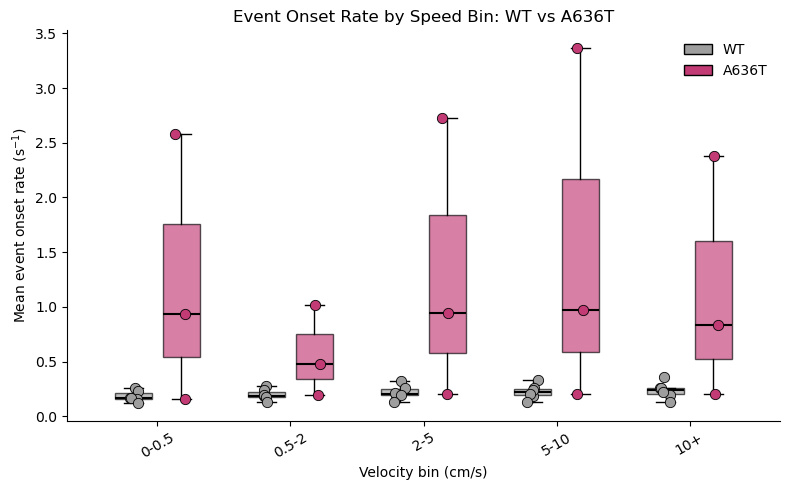

In [18]:
## mice are 
# WT: [992, 994, 989, 757, 326, 311]
# A636T mutant: [752, 328, 388]

wt_ids = [992, 994, 989, 757, 326, 311]
mut_ids = [752, 328, 388]

wt_mice = [f"m{x}" for x in wt_ids]
mut_mice = [f"m{x}" for x in mut_ids]

# one value per mouse per speed bin
mouse_bin_summary = (
    all_onsets_df
    .groupby(["mouse", "speed_bin_low", "speed_bin_high"], dropna=False)["avg_rate_onsets"]
    .mean()
    .reset_index(name="mouse_mean_onset_rate")
)

# assign genotype safely
mouse_bin_summary["genotype"] = pd.Series(pd.NA, index=mouse_bin_summary.index, dtype="object")
mouse_bin_summary.loc[mouse_bin_summary["mouse"].isin(wt_mice), "genotype"] = "WT"
mouse_bin_summary.loc[mouse_bin_summary["mouse"].isin(mut_mice), "genotype"] = "A636T"

mouse_bin_summary = mouse_bin_summary.dropna(subset=["genotype"]).copy()

bin_order = [(0, 0.5), (0.5, 2), (2, 5), (5, 10), (10, np.inf)]

def format_bin_label(lo, hi):
    if np.isinf(hi):
        return f"{lo:g}+"
    return f"{lo:g}-{hi:g}"

bin_labels = [format_bin_label(lo, hi) for lo, hi in bin_order]

colors = {"WT": "#9e9e9e", "A636T": "#c23b75"}
offsets = {"WT": -0.18, "A636T": 0.18}
box_width = 0.28

rng = np.random.default_rng(7)

fig, ax = plt.subplots(figsize=(8, 5))

for i, (lo, hi) in enumerate(bin_order):
    for genotype in ["WT", "A636T"]:
        sub = mouse_bin_summary.loc[
            (mouse_bin_summary["speed_bin_low"] == lo) &
            (mouse_bin_summary["speed_bin_high"] == hi) &
            (mouse_bin_summary["genotype"] == genotype)
        ].copy()

        if sub.empty:
            continue

        vals = sub["mouse_mean_onset_rate"].to_numpy()
        xpos = i + offsets[genotype]

        ax.boxplot(
            [vals],
            positions=[xpos],
            widths=box_width,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(facecolor=colors[genotype], edgecolor="black", alpha=0.65),
            medianprops=dict(color="black", linewidth=1.5),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
        )

        jitter = rng.uniform(-0.045, 0.045, len(sub))
        ax.scatter(
            np.full(len(sub), xpos) + jitter,
            vals,
            s=55,
            color=colors[genotype],
            edgecolor="black",
            linewidth=0.6,
            zorder=3,
        )

ax.set_xticks(range(len(bin_order)))
ax.set_xticklabels(bin_labels, rotation=30)
ax.set_xlabel("Velocity bin (cm/s)")
ax.set_ylabel("Mean event onset rate (s$^{-1}$)")
ax.set_title("Event Onset Rate by Speed Bin: WT vs A636T")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    handles=[
        Patch(facecolor=colors["WT"], edgecolor="black", label="WT"),
        Patch(facecolor=colors["A636T"], edgecolor="black", label="A636T"),
    ],
    frameon=False
)

plt.tight_layout()

save_dir = Path("/Users/johnmarshall/Documents/Presentations/05192026")
save_dir.mkdir(parents=True, exist_ok=True)
pdf_path = save_dir / "WT_vs_A636T_binned_event_onset_rate.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
print(pdf_path)

plt.show()



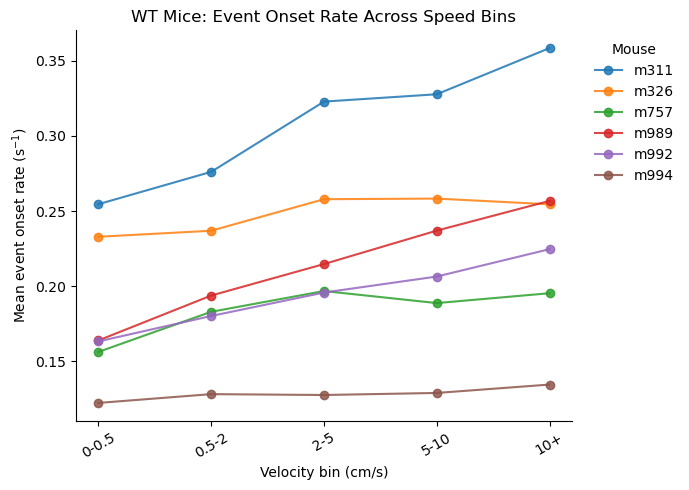

In [20]:
# WT mice
wt_ids = [992, 994, 989, 757, 326, 311]
wt_mice = [f"m{x}" for x in wt_ids]

# one value per mouse per speed bin
wt_summary = (
    all_onsets_df.loc[all_onsets_df["mouse"].isin(wt_mice)]
    .groupby(["mouse", "speed_bin_low", "speed_bin_high"], dropna=False)["avg_rate_onsets"]
    .mean()
    .reset_index(name="mouse_mean_onset_rate")
)

bin_order = [(0, 0.5), (0.5, 2), (2, 5), (5, 10), (10, np.inf)]

def format_bin_label(lo, hi):
    if np.isinf(hi):
        return f"{lo:g}+"
    return f"{lo:g}-{hi:g}"

bin_labels = [format_bin_label(lo, hi) for lo, hi in bin_order]

# map bins to x positions
bin_to_x = {b: i for i, b in enumerate(bin_order)}

fig, ax = plt.subplots(figsize=(7, 5))

for mouse in sorted(wt_summary["mouse"].unique()):
    sub = wt_summary.loc[wt_summary["mouse"] == mouse].copy()

    sub["bin_tuple"] = list(zip(sub["speed_bin_low"], sub["speed_bin_high"]))
    sub["x"] = sub["bin_tuple"].map(bin_to_x)
    sub = sub.sort_values("x")

    ax.plot(
        sub["x"],
        sub["mouse_mean_onset_rate"],
        marker="o",
        linewidth=1.5,
        markersize=6,
        alpha=0.85,
        label=mouse
    )

ax.set_xticks(range(len(bin_order)))
ax.set_xticklabels(bin_labels, rotation=30)
ax.set_xlabel("Velocity bin (cm/s)")
ax.set_ylabel("Mean event onset rate (s$^{-1}$)")
ax.set_title("WT Mice: Event Onset Rate Across Speed Bins")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(title="Mouse", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

pdf_path = save_dir / "WT_event_onset_rate_across_speed_bins.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

plt.show()


/Users/johnmarshall/Documents/Presentations/05192026/m989_occupancy_heatmap_with_profile.pdf


/var/folders/fc/24x3k2m92bvbv7ck1v5mt3n40000gn/T/ipykernel_98478/646038616.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


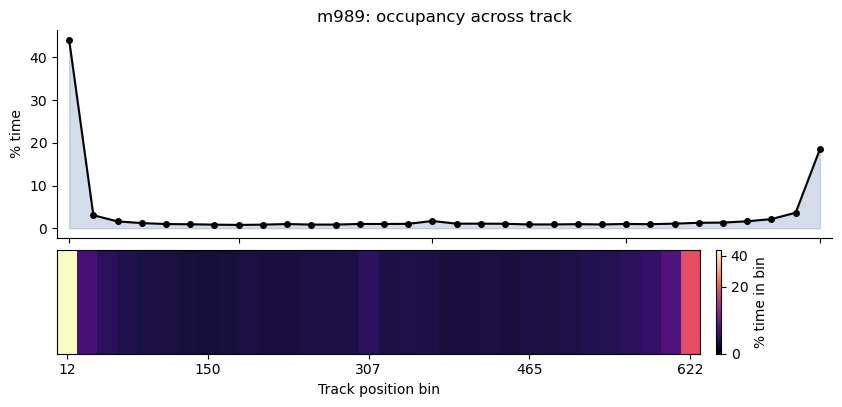

In [24]:
## occupancy plot for one animal
# choose one mouse
analysis_name = "m989_analysis"
n_x_bins = 32
sampling_period_s = 0.05  # 20 Hz miniscope-aligned samples

gcamp_path = base_dir / analysis_name / "GCAMP_with_velocity.csv"
gcamp_df = pd.read_csv(gcamp_path, index_col=0).reset_index(drop=True)

# use X position only for linear-track occupancy
x = pd.to_numeric(gcamp_df["X_coor"], errors="coerce").dropna()

# bin edges spanning this mouse's observed track range
x_edges = np.linspace(x.min(), x.max(), n_x_bins + 1)

# occupancy counts and time
occupancy_counts, _ = np.histogram(x, bins=x_edges)
occupancy_s = occupancy_counts * sampling_period_s

occupancy_df = pd.DataFrame({
    "x_bin": np.arange(n_x_bins),
    "x_left": x_edges[:-1],
    "x_right": x_edges[1:],
    "occupancy_counts": occupancy_counts,
    "occupancy_s": occupancy_s,
})

# convert to percent time in each bin
occupancy_pct = 100 * occupancy_df["occupancy_s"].to_numpy() / occupancy_df["occupancy_s"].sum()

# tweak this: smaller gamma = more contrast in low/mid occupancy bins
gamma = 0.25

fig, (ax_top, ax_heat) = plt.subplots(
    2, 1,
    figsize=(10, 4.2),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08}
)

x = np.arange(n_x_bins)

# top line plot
ax_top.plot(x, occupancy_pct, color="black", linewidth=1.5, marker="o", markersize=4)
ax_top.fill_between(x, occupancy_pct, color="#4c78a8", alpha=0.25)
ax_top.set_ylabel("% time")
ax_top.set_title(f"{analysis_name.replace('_analysis', '')}: occupancy across track")
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)

# bottom heatmap
im = ax_heat.imshow(
    occupancy_pct[np.newaxis, :],
    aspect="auto",
    cmap="magma",
    interpolation="nearest",
    norm=mcolors.PowerNorm(gamma=gamma, vmin=0, vmax=occupancy_pct.max())
)

ax_heat.set_yticks([])
ax_heat.set_xlabel("Track position bin")

tick_idx = np.linspace(0, n_x_bins - 1, 5).astype(int)
tick_labels = [f"{occupancy_df.loc[i, 'x_left']:.0f}" for i in tick_idx]
ax_heat.set_xticks(tick_idx)
ax_heat.set_xticklabels(tick_labels)

cbar = plt.colorbar(im, ax=ax_heat, pad=0.02)
cbar.set_label("% time in bin")

plt.tight_layout()

save_dir = Path("/Users/johnmarshall/Documents/Presentations/05192026")
save_dir.mkdir(parents=True, exist_ok=True)

pdf_path = save_dir / f"{analysis_name.replace('_analysis', '')}_occupancy_heatmap_with_profile.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

print(pdf_path)
plt.show()


/Users/johnmarshall/Documents/Presentations/05192026/WT_vs_A636T_average_occupancy_side_by_side.pdf


/var/folders/fc/24x3k2m92bvbv7ck1v5mt3n40000gn/T/ipykernel_98478/3682505734.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


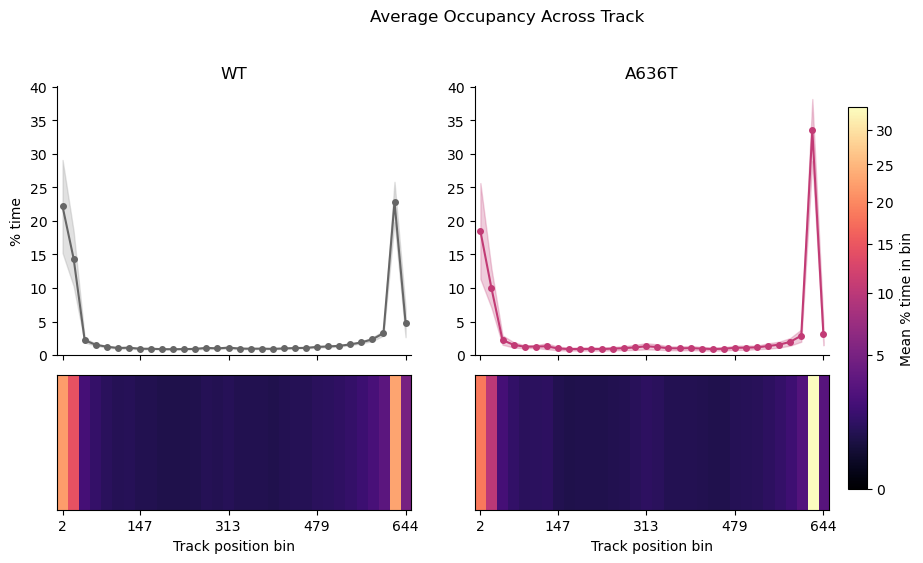

In [25]:
# groups
wt_ids = [992, 994, 989, 757, 326, 311]
mut_ids = [752, 328, 388]

wt_mice = [f"m{x}" for x in wt_ids]
mut_mice = [f"m{x}" for x in mut_ids]
all_mice = wt_mice + mut_mice

n_x_bins = 32
sampling_period_s = 0.05
gamma = 0.55

# common x-bin edges across all mice
all_x = []
for mouse in all_mice:
    gcamp_path = base_dir / f"{mouse}_analysis" / "GCAMP_with_velocity.csv"
    if not gcamp_path.exists():
        continue
    gcamp_df = pd.read_csv(gcamp_path, index_col=0).reset_index(drop=True)
    x = pd.to_numeric(gcamp_df["X_coor"], errors="coerce").dropna().to_numpy()
    if len(x) > 0:
        all_x.append(x)

x_concat = np.concatenate(all_x)
x_edges = np.linspace(np.nanmin(x_concat), np.nanmax(x_concat), n_x_bins + 1)

# per-mouse occupancy profile as % time in each bin
rows = []
for mouse in all_mice:
    gcamp_path = base_dir / f"{mouse}_analysis" / "GCAMP_with_velocity.csv"
    if not gcamp_path.exists():
        continue

    gcamp_df = pd.read_csv(gcamp_path, index_col=0).reset_index(drop=True)
    x = pd.to_numeric(gcamp_df["X_coor"], errors="coerce").dropna().to_numpy()
    if len(x) == 0:
        continue

    counts, _ = np.histogram(x, bins=x_edges)
    occ_s = counts * sampling_period_s
    occ_pct = 100 * occ_s / occ_s.sum()

    genotype = "WT" if mouse in wt_mice else "A636T"

    for bin_idx in range(n_x_bins):
        rows.append({
            "mouse": mouse,
            "genotype": genotype,
            "x_bin": bin_idx,
            "x_left": x_edges[bin_idx],
            "x_right": x_edges[bin_idx + 1],
            "occupancy_pct": occ_pct[bin_idx],
        })

occupancy_pct_df = pd.DataFrame(rows)

group_occ_summary = (
    occupancy_pct_df
    .groupby(["genotype", "x_bin", "x_left", "x_right"])["occupancy_pct"]
    .agg(["mean", "sem"])
    .reset_index()
)

wt_summary = group_occ_summary.loc[group_occ_summary["genotype"] == "WT"].sort_values("x_bin")
mut_summary = group_occ_summary.loc[group_occ_summary["genotype"] == "A636T"].sort_values("x_bin")

shared_ymax = max(
    (wt_summary["mean"] + wt_summary["sem"]).max(),
    (mut_summary["mean"] + mut_summary["sem"]).max()
) * 1.05

vmax = max(wt_summary["mean"].max(), mut_summary["mean"].max())
x = np.arange(n_x_bins)

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 5.5),
    sharex="col",
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.10, "wspace": 0.18}
)

ax_wt_line, ax_mut_line = axes[0]
ax_wt_heat, ax_mut_heat = axes[1]

# WT line
ax_wt_line.plot(x, wt_summary["mean"], color="#666666", marker="o", markersize=4, linewidth=1.5)
ax_wt_line.fill_between(
    x,
    wt_summary["mean"] - wt_summary["sem"],
    wt_summary["mean"] + wt_summary["sem"],
    color="#9e9e9e",
    alpha=0.30
)
ax_wt_line.set_title("WT")
ax_wt_line.set_ylabel("% time")
ax_wt_line.set_ylim(0, shared_ymax)
ax_wt_line.spines["top"].set_visible(False)
ax_wt_line.spines["right"].set_visible(False)

# Mutant line
ax_mut_line.plot(x, mut_summary["mean"], color="#c23b75", marker="o", markersize=4, linewidth=1.5)
ax_mut_line.fill_between(
    x,
    mut_summary["mean"] - mut_summary["sem"],
    mut_summary["mean"] + mut_summary["sem"],
    color="#c23b75",
    alpha=0.25
)
ax_mut_line.set_title("A636T")
ax_mut_line.set_ylim(0, shared_ymax)
ax_mut_line.spines["top"].set_visible(False)
ax_mut_line.spines["right"].set_visible(False)

# WT heatmap
im = ax_wt_heat.imshow(
    wt_summary["mean"].to_numpy()[np.newaxis, :],
    aspect="auto",
    cmap="magma",
    interpolation="nearest",
    norm=mcolors.PowerNorm(gamma=gamma, vmin=0, vmax=vmax)
)
ax_wt_heat.set_yticks([])
ax_wt_heat.set_xlabel("Track position bin")

# Mutant heatmap
ax_mut_heat.imshow(
    mut_summary["mean"].to_numpy()[np.newaxis, :],
    aspect="auto",
    cmap="magma",
    interpolation="nearest",
    norm=mcolors.PowerNorm(gamma=gamma, vmin=0, vmax=vmax)
)
ax_mut_heat.set_yticks([])
ax_mut_heat.set_xlabel("Track position bin")

tick_idx = np.linspace(0, n_x_bins - 1, 5).astype(int)
tick_labels = [f"{x_edges[i]:.0f}" for i in tick_idx]

for ax in [ax_wt_heat, ax_mut_heat]:
    ax.set_xticks(tick_idx)
    ax.set_xticklabels(tick_labels)

cbar = fig.colorbar(im, ax=axes, pad=0.02, shrink=0.9)
cbar.set_label("Mean % time in bin")

fig.suptitle("Average Occupancy Across Track", y=1.02)

plt.tight_layout()

save_dir = Path("/Users/johnmarshall/Documents/Presentations/05192026")
save_dir.mkdir(parents=True, exist_ok=True)
pdf_path = save_dir / "WT_vs_A636T_average_occupancy_side_by_side.pdf"
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

print(pdf_path)
plt.show()


In [58]:
# choose one mouse
analysis_name = "m757_analysis"

# choose which onset-rate file to use
# use the LocalMax version if you want the more conservative onset detection
#onset_rate_filename = "instantaneousEventRateOnsets_LocalMax.csv"
onset_rate_filename = "instantaneousEventRateOnsets.csv"

analysis_dir = base_dir / analysis_name

gcamp_path = analysis_dir / "GCAMP_with_velocity.csv"
onsets_path = analysis_dir / onset_rate_filename

gcamp_df = pd.read_csv(gcamp_path, index_col=0).reset_index(drop=True)
onsets_df = pd.read_csv(onsets_path, index_col=0).reset_index(drop=True)

if len(gcamp_df) != len(onsets_df):
    raise ValueError(
        f"Length mismatch: len(gcamp_df)={len(gcamp_df)} vs len(onsets_df)={len(onsets_df)}"
    )

# inspect available sessions inside this concatenated mouse file
available_sessions = sorted(gcamp_df["ezTrackOutput"].dropna().astype(str).unique())

for i, s in enumerate(available_sessions):
    print(i, Path(s).name)


0 m757_01102024_13_17_54_concactenatedbehavCam00_behavCam04_rotated_cropped_LocationOutput.csv
1 m757_02102024_15_25_28_concactenatedbehavCam00_behavCam17_rotated_cropped_LocationOutput.csv
2 m757_03102024_14_18_22_concactenatedbehavCam00_behavCam17_rotated_cropped_LocationOutput.csv
3 m757_04102024_17_05_49_concactenatedbehavCam00_behavCam17_rotated_cropped_LocationOutput.csv
4 m757_10102024_15_50_07_concactenatedbehavCam00_behavCam17_rotated_cropped_LocationOutput.csv


In [48]:
# choose one session from the printed list above
session_idx = 0
session_src = available_sessions[session_idx]
session_label = Path(session_src).name.replace("_LocationOutput.csv", "")

mask = gcamp_df["ezTrackOutput"].astype(str) == session_src

session_gcamp = gcamp_df.loc[mask].reset_index(drop=True)
session_onsets = onsets_df.loc[mask].reset_index(drop=True)

# append position columns needed for spatial binning
session_onsets["X_coor"] = session_gcamp["X_coor"].to_numpy()
session_onsets["Y_coor"] = session_gcamp["Y_coor"].to_numpy()
session_onsets["closestBehavCamFrameIdx"] = session_gcamp["closestBehavCamFrameIdx"].to_numpy()

# compute spatially binned onset-rate heatmap input
spatial_rates_onsets = avg_rate_by_spatial_bins(
    session_onsets,
    n_bins=32,
    x_col="X_coor",
    cell_prefix="cell_"
)

spatial_rates_onsets_normalized = normalize_peak_to_one(
    spatial_rates_onsets,
    cell_prefix="cell_"
)

spatial_rates_onsets.head()


,cell_0,cell_1,cell_4,cell_5,cell_6,cell_7,cell_8,cell_10,cell_11,cell_12,...,cell_655,cell_656,cell_657,cell_658,cell_660,cell_661,n_samples,x_left,x_right,x_center
x_bin,,,,,,,,,,,,,,,,,,,,,
0,0.465842,0.057218,0.566724,0.324934,0.054489,0.190303,0.815792,0.120531,0.190485,0.335941,...,0.410807,0.382425,0.211953,0.016283,0.492404,0.264441,10993,13.692842,33.270104,23.481473
1,0.581690,0.033803,0.461972,0.383099,0.026761,0.063380,0.760563,0.287324,0.070423,0.364789,...,0.309859,0.514085,0.491549,0.046479,0.545070,0.078873,710,33.270104,52.847365,43.058735
2,0.545205,0.035616,0.561644,0.627397,0.030137,0.090411,0.731507,0.493151,0.178082,0.186301,...,0.260274,0.652055,0.416438,0.035616,0.536986,0.142466,365,52.847365,72.424627,62.635996
3,0.491039,0.064516,0.473118,0.372760,0.021505,0.064516,0.835125,0.322581,0.236559,0.222222,...,0.146953,0.688172,0.347670,0.078853,0.637993,0.143369,279,72.424627,92.001889,82.213258
4,0.549383,0.037037,0.361111,0.425926,0.006173,0.049383,0.709877,0.280864,0.271605,0.493827,...,0.280864,0.611111,0.419753,0.138889,0.558642,0.095679,324,92.001889,111.579150,101.790519


/Users/johnmarshall/Documents/Presentations/05192026/m989_m989_01012025_15_29_53_concactenatedbehavCam00_behavCam17_rotated_cropped_spatial_onsets_raw.pdf


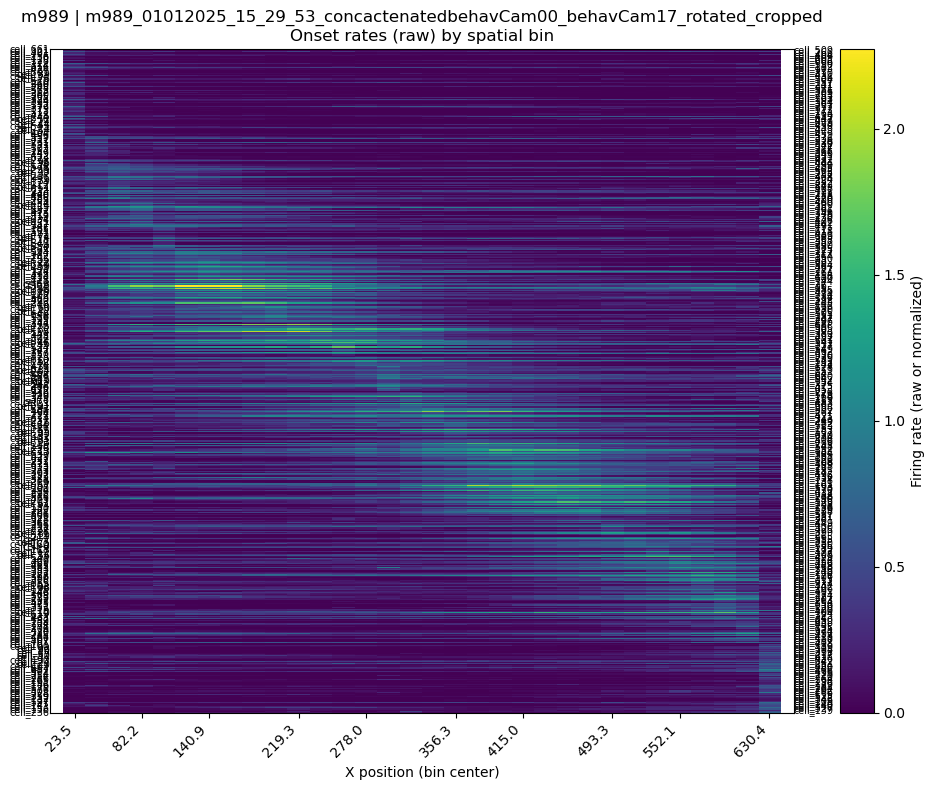

/Users/johnmarshall/Documents/Presentations/05192026/m989_m989_01012025_15_29_53_concactenatedbehavCam00_behavCam17_rotated_cropped_spatial_onsets_normalized.pdf


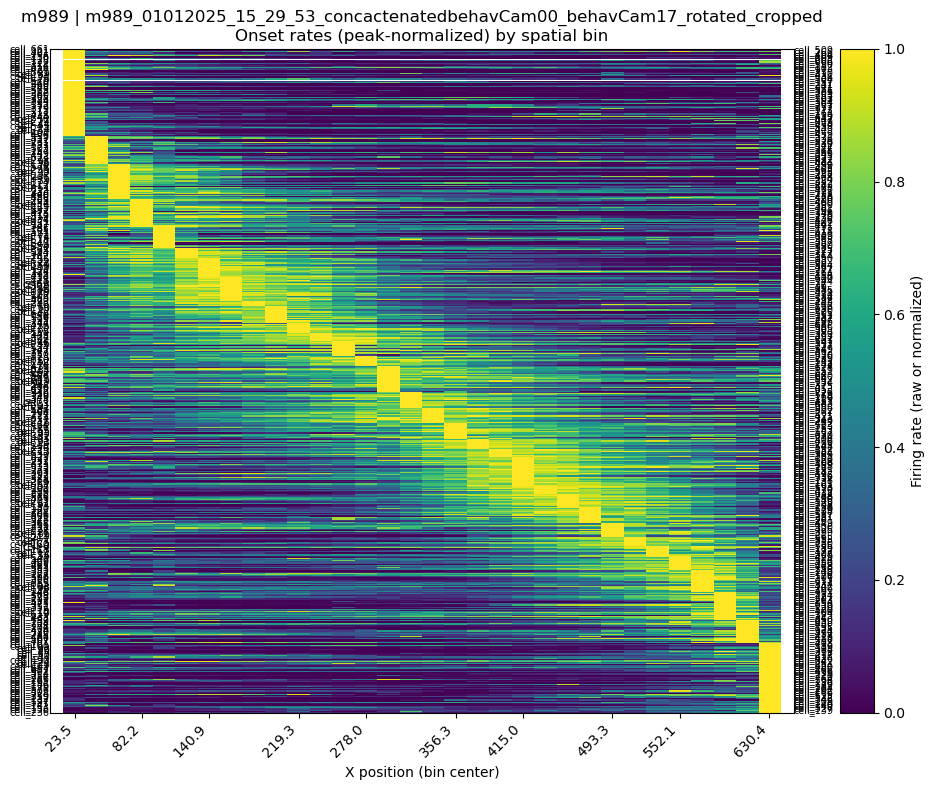

In [49]:
save_dir = Path("/Users/johnmarshall/Documents/Presentations/05192026")
save_dir.mkdir(parents=True, exist_ok=True)

plot_spatial_rate_heatmap(
    spatial_rates_onsets,
    title=f"{analysis_name.replace('_analysis', '')} | {session_label}\nOnset rates (raw) by spatial bin",
    sort_by_peak_bin=True,
    save_path=save_dir / f"{analysis_name.replace('_analysis', '')}_{session_label}_spatial_onsets_raw.pdf",
)

plot_spatial_rate_heatmap(
    spatial_rates_onsets_normalized,
    title=f"{analysis_name.replace('_analysis', '')} | {session_label}\nOnset rates (peak-normalized) by spatial bin",
    sort_by_peak_bin=True,
    save_path=save_dir / f"{analysis_name.replace('_analysis', '')}_{session_label}_spatial_onsets_normalized.pdf",
)


In [56]:
# session that defines the cell order
plot_order_session = available_sessions[0]

# session you want to visualize using that same order
plot_session = available_sessions[7]

order_label = Path(plot_order_session).name.replace("_LocationOutput.csv", "")
plot_label = Path(plot_session).name.replace("_LocationOutput.csv", "")

# build reference session
ref_gcamp, ref_onsets = get_session_subset(gcamp_df, onsets_df, plot_order_session)
ref_spatial_rates_onsets = avg_rate_by_spatial_bins(
    ref_onsets,
    n_bins=32,
    x_col="X_coor",
    cell_prefix="cell_"
)
ref_spatial_rates_onsets_normalized = normalize_peak_to_one(ref_spatial_rates_onsets, cell_prefix="cell_")

# build target session
plot_gcamp, plot_onsets = get_session_subset(gcamp_df, onsets_df, plot_session)
plot_spatial_rates_onsets = avg_rate_by_spatial_bins(
    plot_onsets,
    n_bins=32,
    x_col="X_coor",
    cell_prefix="cell_"
)
plot_spatial_rates_onsets_normalized = normalize_peak_to_one(plot_spatial_rates_onsets, cell_prefix="cell_")

# define cell order from the reference session
ordered_cells = get_peak_sorted_cell_order(ref_spatial_rates_onsets, cell_prefix="cell_")

# keep only cells present in both sessions
ordered_cells_common = [c for c in ordered_cells if c in plot_spatial_rates_onsets.columns]

print(f"Reference session for order: {order_label}")
print(f"Session being plotted:       {plot_label}")
print(f"Common ordered cells:       {len(ordered_cells_common)}")


Reference session for order: m989_01012025_15_29_53_concactenatedbehavCam00_behavCam17_rotated_cropped
Session being plotted:       m989_10012025_17_42_02_concactenatedbehavCam00_behavCam17_rotated_cropped
Common ordered cells:       587


/Users/johnmarshall/Documents/Presentations/05192026/m989_m989_01012025_15_29_53_concactenatedbehavCam00_behavCam17_rotated_cropped_reference_same_order_normalized.pdf


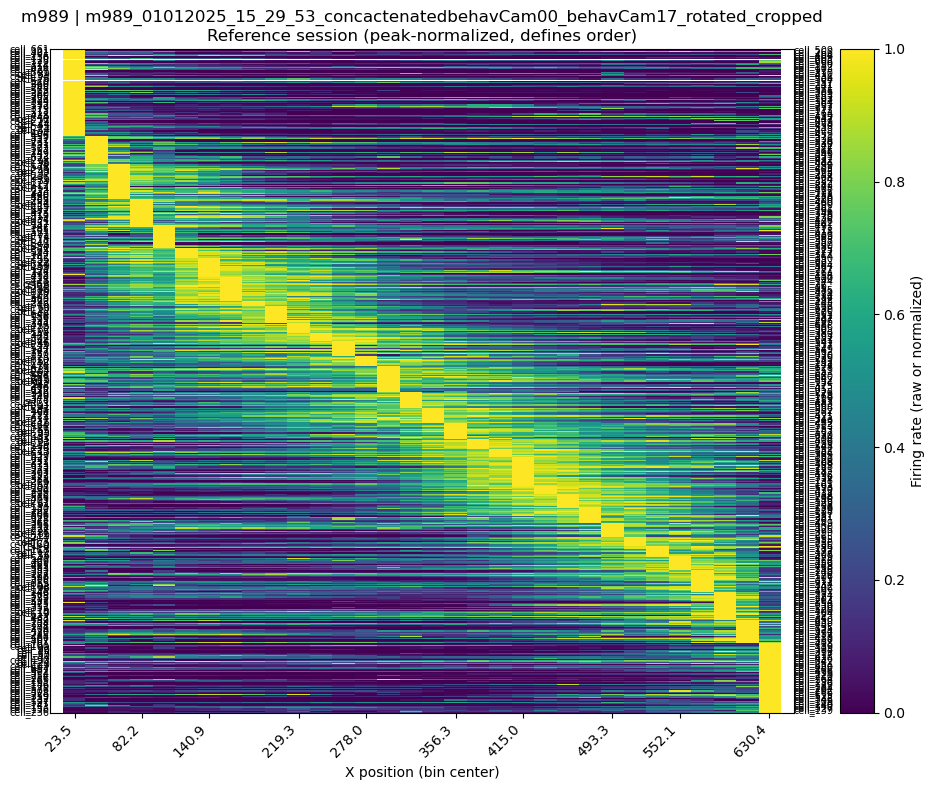

/Users/johnmarshall/Documents/Presentations/05192026/m989_m989_10012025_17_42_02_concactenatedbehavCam00_behavCam17_rotated_cropped_target_same_order_normalized.pdf


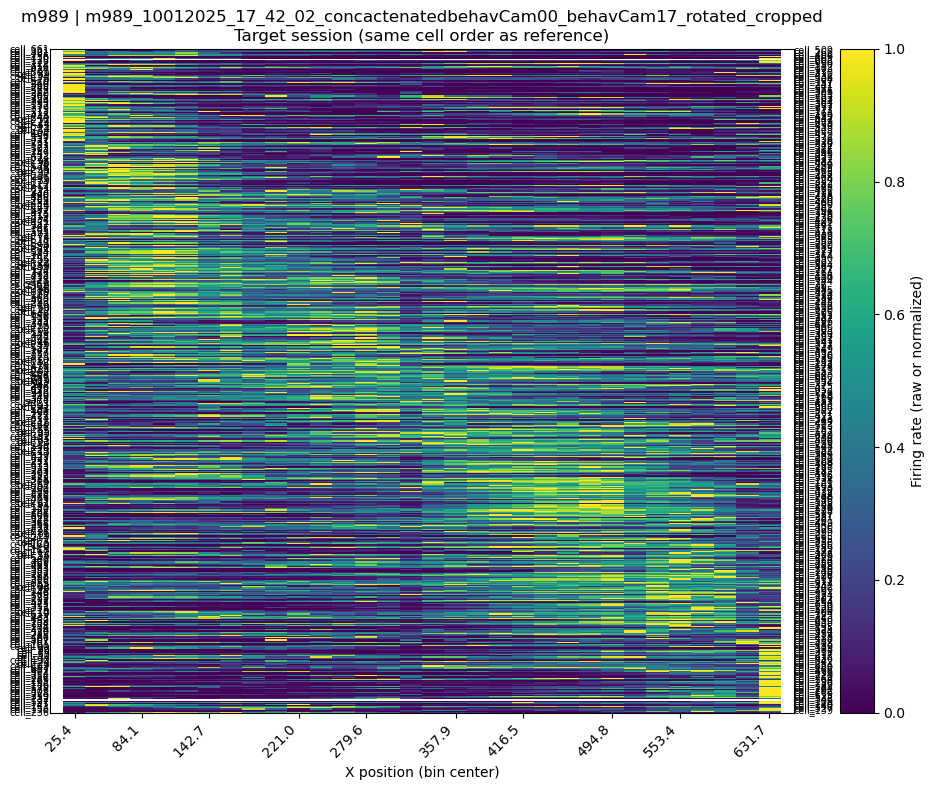

In [57]:
save_dir = Path("/Users/johnmarshall/Documents/Presentations/05192026")
save_dir.mkdir(parents=True, exist_ok=True)

plot_spatial_rate_heatmap(
    ref_spatial_rates_onsets_normalized,
    cells=ordered_cells_common,
    title=f"{analysis_name.replace('_analysis', '')} | {order_label}\nReference session (peak-normalized, defines order)",
    sort_by_peak_bin=False,
    save_path=save_dir / f"{analysis_name.replace('_analysis', '')}_{order_label}_reference_same_order_normalized.pdf",
)

plot_spatial_rate_heatmap(
    plot_spatial_rates_onsets_normalized,
    cells=ordered_cells_common,
    title=f"{analysis_name.replace('_analysis', '')} | {plot_label}\nTarget session (same cell order as reference)",
    sort_by_peak_bin=False,
    save_path=save_dir / f"{analysis_name.replace('_analysis', '')}_{plot_label}_target_same_order_normalized.pdf",
)



In [ ]:
###





## load everything from the *saved events .csv file 
def get_event_rate_same_length(df, samplingRate, pad_value=0):
    """
    Forward-looking 1-second window sums, same length as input.
    """
    arr = df.to_numpy(dtype=int)
    kernel = np.ones(samplingRate, dtype=int)

    pad = samplingRate - 1
    arr_pad = np.pad(arr, ((0, pad), (0, 0)), mode="constant", constant_values=pad_value)

    rates = np.apply_along_axis(
        lambda col: np.convolve(col, kernel, mode="valid"),
        axis=0,
        arr=arr_pad
    )
    return pd.DataFrame(rates, index=df.index, columns=df.columns)


base_dir = Path("/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/LinearTrackDataAlignedAcrossDays")
analysis_dirs = sorted(base_dir.glob("m*_analysis"))

samplingRate = 20
event_index_col = "onset_idx"   # use "peak_idx" instead if you want local-max timing rather than onset timing

summary_rows = []

for analysis_dir in analysis_dirs:
    gcamp_path = analysis_dir / "GCAMP_with_velocity.csv"
    stats_path = analysis_dir / "all_peak_stats.csv"
    out_path = analysis_dir / "instantaneousEventRateOnsets_LocalMax.csv"

    if not (gcamp_path.exists() and stats_path.exists()):
        summary_rows.append({
            "analysis_dir": analysis_dir.name,
            "status": "missing_input_csv"
        })
        continue

    print(f"Processing {analysis_dir.name}")

    try:
        gcamp_df = pd.read_csv(gcamp_path, index_col=0).reset_index(drop=True)
        stats_df = pd.read_csv(stats_path)

        cell_cols = [c for c in gcamp_df.columns if c.startswith("cell_")]
        n_rows = len(gcamp_df)

        # binary matrix of conservative event onsets
        localmax_onsets = pd.DataFrame(0, index=np.arange(n_rows), columns=cell_cols, dtype=int)

        if not stats_df.empty:
            required_cols = {"cell", event_index_col}
            missing_cols = required_cols - set(stats_df.columns)
            if missing_cols:
                raise KeyError(f"{stats_path.name} missing required columns: {missing_cols}")

            events_df = (
                stats_df.loc[:, ["cell", event_index_col]]
                .dropna()
                .copy()
            )
            events_df[event_index_col] = events_df[event_index_col].astype(int)
            events_df = events_df[events_df["cell"].isin(cell_cols)]
            events_df = events_df[
                (events_df[event_index_col] >= 0) &
                (events_df[event_index_col] < n_rows)
            ]

            for cell_name, idxs in events_df.groupby("cell")[event_index_col]:
                localmax_onsets.loc[np.unique(idxs.to_numpy()), cell_name] = 1

        instantaneousEventRateOnsets_LocalMax = (
            get_event_rate_same_length(localmax_onsets, samplingRate=samplingRate)
            .reset_index(drop=True)
        )

        instantaneousEventRateOnsets_LocalMax.to_csv(out_path, index=True)

        summary_rows.append({
            "analysis_dir": analysis_dir.name,
            "status": "ok",
            "n_rows": n_rows,
            "n_cells": len(cell_cols),
            "n_events_from_stats": 0 if stats_df.empty else len(stats_df),
            "output_csv": str(out_path),
        })

    except Exception as e:
        summary_rows.append({
            "analysis_dir": analysis_dir.name,
            "status": "error",
            "error": str(e),
        })

summary_df_localmax_onsets = pd.DataFrame(summary_rows)
summary_df_localmax_onsets
